# **BÀI 1**

**1)**

In [3]:
import numpy as np
cau = ["I love playing basketball",
       "Basketball is one of my favourite sports",
       "LeBron James is the goat",
       "Machine learning is complex",
       "I love MLIoT Lab",
       "Machine learning is a small part of Artificial Intelligence",
       "Ronaldo is playing in his last World Cup",
       "There are more players in football than in basketball"]
vocab = sorted({w for s in cau for w in s.lower().split()})
def to_vecto(s):
  v = np.zeros(len(vocab))
  for w in s.lower().split():
    if w in vocab:
      v[vocab.index(w)] += 1
  return v
X = np.array([to_vecto(s) for s in cau])
print(X.shape)


(8, 36)


Với X.shape, mỗi hàng đại diện cho 1 câu và mỗi cột đại diện cho những từ phân biệt có trong toàn bộ các câu (ở đây gồm 8 câu và 36 từ khác nhau).

Giá trị trong ma trận là số lần từ đã xuất hiện trong câu.


**2)**

In [4]:
mean = X.mean(axis=0)
print(mean.shape)
print(X-mean)


(36,)
[[-0.125 -0.125 -0.125  0.625 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125
   0.75  -0.375 -0.125 -0.625 -0.125 -0.125 -0.125 -0.25  -0.125  0.75
  -0.25  -0.125 -0.125 -0.125 -0.25  -0.125 -0.125 -0.125  0.75  -0.125
  -0.125 -0.125 -0.125 -0.125 -0.125 -0.125]
 [-0.125 -0.125 -0.125  0.625 -0.125 -0.125  0.875 -0.125 -0.125 -0.125
  -0.25  -0.375 -0.125  0.375 -0.125 -0.125 -0.125 -0.25  -0.125 -0.25
  -0.25  -0.125 -0.125  0.875  0.75   0.875 -0.125 -0.125 -0.25  -0.125
  -0.125  0.875 -0.125 -0.125 -0.125 -0.125]
 [-0.125 -0.125 -0.125 -0.375 -0.125 -0.125 -0.125 -0.125  0.875 -0.125
  -0.25  -0.375 -0.125  0.375  0.875 -0.125 -0.125 -0.25   0.875 -0.25
  -0.25  -0.125 -0.125 -0.125 -0.25  -0.125 -0.125 -0.125 -0.25  -0.125
  -0.125 -0.125 -0.125  0.875 -0.125 -0.125]
 [-0.125 -0.125 -0.125 -0.375  0.875 -0.125 -0.125 -0.125 -0.125 -0.125
  -0.25  -0.375 -0.125  0.375 -0.125 -0.125 -0.125  0.75  -0.125 -0.25
   0.75  -0.125 -0.125 -0.125 -0.25  -0.125 -0.125 -0.125 -0.25  -0.125

Lệnh mean = X.mean(axis=0) sẽ tính và trả về giá trị trung bình của từng cột trong X nên mean là 1 vecto gồm 36 phần tử. Khi ta lấy ma trận X trừ đi cho mean, hai kích thước của ma trận sẽ không khớp nhau, nhưng vì quy tắc broadcasting của NumPy nên vecto mean sẽ được copy và ghép thành từng hàng sao cho khớp với kích thước của X (copy 8 lần để thành ma trận 8x36), sau đó mới thực hiện phép tính.

**3)**

In [5]:
def cosine_similarity(X, Y = None):
  if Y is None:
    Y = X
  Xn = X / np.linalg.norm(X, axis = 1, keepdims=True)
  Yn = Y / np.linalg.norm(Y, axis = 1, keepdims=True)
  return Xn @ Yn.T
print(cosine_similarity(X))

[[1.         0.18898224 0.         0.         0.5        0.
  0.1767767  0.15075567]
 [0.18898224 1.         0.16903085 0.18898224 0.         0.25197632
  0.13363062 0.11396058]
 [0.         0.16903085 1.         0.2236068  0.         0.1490712
  0.15811388 0.        ]
 [0.         0.18898224 0.2236068  1.         0.         0.5
  0.1767767  0.        ]
 [0.5        0.         0.         0.         1.         0.
  0.         0.        ]
 [0.         0.25197632 0.1490712  0.5        0.         1.
  0.11785113 0.        ]
 [0.1767767  0.13363062 0.15811388 0.1767767  0.         0.11785113
  1.         0.21320072]
 [0.15075567 0.11396058 0.         0.         0.         0.
  0.21320072 1.        ]]


**4)**

In [6]:
def search(query, top_k = 3):
  q_vecto = to_vecto(query)
  q_matrix = q_vecto.reshape(1, -1)
  res = cosine_similarity(X, q_matrix).flatten()
  idx = np.argsort(res)[-top_k:][::-1]
  return [(cau[i], float(round(res[i],3))) for i in idx]


print(search("Lebron James and Ronaldo are the goat"))

[('LeBron James is the goat', 0.73), ('Ronaldo is playing in his last World Cup', 0.144), ('There are more players in football than in basketball', 0.123)]


Cặp giống nhau nhất là: "Lebron James and Ronaldo are the goat" với "LeBron James is the goat", tương đồng rất nhiều.

Cặp khác nhau nhất là: "Lebron James and Ronaldo are the goat" với "'There are more players in football than in basketball".

Nếu nhìn trực giác về top 3 câu khớp với query thì em nghĩ là khá chính xác vì câu 1 thì giống nhau rất nhiều, chỉ khác mỗi chủ ngữ của query có thêm Ronaldo, câu 2 thì có đề cập tới Ronaldo giống query và câu 3 thì có chủ đề cùng với bóng đá và bóng rổ.

**5)**
Theo kết quả của ma trận tương đồng trong câu 3 thì ta thấy được:

Cặp giống nhau nhất với cosine = 0.5: câu 1 và 5 ("I love playing basketball" và "I love MLIoT"), câu 4 và 6 ("Machine learning is complex" và "Machine learning is a small part of Artificial Intelligence")

Có rất nhiều cặp khác nhau nhất với cosine = 0 (nghĩa là không có bất kì từ chung nào), ví dụ như cặp 5 và 8 ("I love MLIoT" và "There are more players in football than in basketball")

Và kết quả thu được chính xác so với trực giác khi ta thấy rằng ở các cặp giống nhau đều có nội dung và cách diễn đạt rất giống nhau ("I love...", "Machine learning is..."), còn ở các cặp khác nhau thì nội dung và cách diễn đạt sẽ không liên quan gì cả.

# **BÀI 2**

[[-0.31960167  1.22675021]
 [ 0.42338181 -0.09586563]
 [ 0.47178864  0.37160747]
 [ 0.83539856 -0.3518397 ]
 [-0.0273151   1.43923027]
 [ 1.72328684 -1.48929716]
 [-0.50886858  0.14247815]
 [-2.5980705  -1.24306362]]


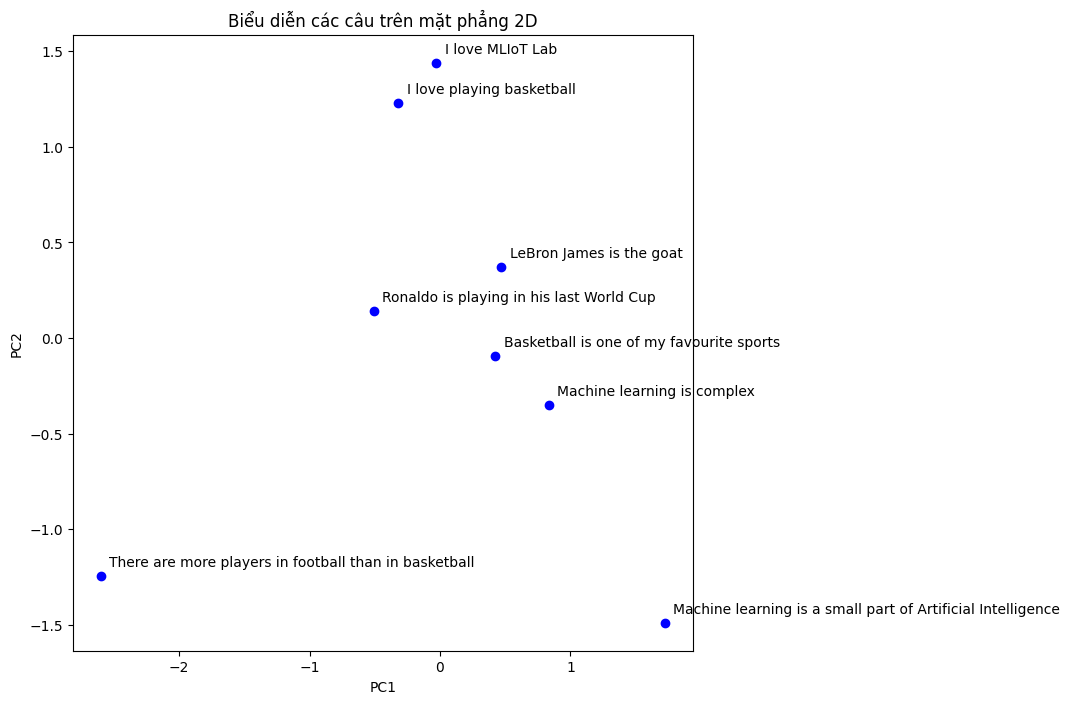

In [11]:
Xc = X-mean
U, S, Vt = np.linalg.svd(Xc, full_matrices = False)
coords = U[:,:2]*S[:2]
# Ở đây đề yêu cầu vẽ các câu trên mặt phẳng 2D => chiếu dữ liệu xuống 2 thành phần chính đầu tiên: PC1 và PC2
# Xc@Vt = U@S, U gồm 8 hàng (tương ứng 8 câu văn) và 2 cột (tương ứng 2 PC), S gồm 2 giá trị kỳ dị tương ứng
# Dùng '*', S sẽ được broadcasting, copy thành 8 hàng, 2 cột và nhân từng phần tử của U với S
print(coords)

import matplotlib.pyplot as plt
plt.figure (figsize=(8,8))
x = coords[:,0]
y = coords[:,1]
plt.scatter(x,y, color = 'blue')
for i in range(len(cau)):
  lable = " ".join(cau[i].split())
  plt.annotate (lable, (x[i],y[i]), xytext = (6,7), textcoords = 'offset points')
plt.title("Biểu diễn các câu trên mặt phẳng 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Nhận xét:

Không gian 2D được thể hiện trên đồ thị được tạo bởi 2 thành phần chính (PC1 và PC2), hay là 2 eigenvectors có eigenvalues lớn nhất mà SVD đã tính ra.

Có những câu cùng chủ đề nằm cạnh nhau như: "I love playing basketball" và "I love MLIoT Lab" cùng nói về sở thích cá nhân.

Nhưng cũng có những câu cùng chủ đề nhưng lại cách xa nhau như: "Machine learning is complex" và "Machine learning is a small part of Artificial Intelligence".

Tuy có cùng chủ đề nhưng 2 câu "Machine learning..." lại chứa nhiều từ vựng khác nhau gây nhiễu, kéo tọa độ của câu đi hướng khác. Còn 2 câu nằm cạnh nhau thì có sự tương đồng rất lớn về mặt cấu trúc từ vựng "I love..." và số từ khác nhau cũng ở mức thấp.

Điều này xảy ra do kích thước dữ liệu quá nhỏ: Thuật toán SVD/PCA hoạt động bằng cách tìm ra các trục chính (đại diện bởi các eigenvectors) mà ở đó dữ liệu phân tán lớn nhất, ta cần rất nhiều văn bản để các trục chính này có thể thực sự đại diện cho một chủ đề nào đó, trong trường hợp này thì 2 trục chính dễ bị nhiễu bởi tần suất của các từ vô nghĩa như "is, of, a ,the" hoặc độ dài câu.

**Bonus:**

In [8]:
cau_bonus = "Messi scored a hattrick in the 2026 World Cup"
X_bonus = np.array([to_vecto(cau_bonus)])
res = cosine_similarity(U*S, X_bonus@Vt.T)
idx = np.argmax(res)
nn = res.flatten()[idx]
print(nn)
print(cau[idx])


0.6942977279965793
Ronaldo is playing in his last World Cup


Độ tương đồng cosine cao nhất là 0.694, bộ phân loại 1-NN hoạt động chính xác khi đưa ra câu tương đồng nhất, có cùng chủ đề bóng đá, đặc biệt là World Cup.

